# Curve Fitting & Interpolation Project
## ENGINEERING COMPUTATION - SPRING 2026 - MIDTERM PROJECT
### Siva R. Sakamuri 


**INTRODUCTION**

This project serves to analyze U.S. quarterly GDP growth rates from 2010 to 2023 using three different numerical methods. These methods include least squares linear regression, polynomial fitting, and cubic spline interpolation. The dataset includes realistic economic fluctuations caused by extreme events such as the COVID-19 outbreak. The realistic nature of the dataset makes it a useful case study for comparing these interpolation and approximation functions. Each method is created and implemented from scratch and applied to the same GDP dataset. To evaluate how well each method represents the trends in the dataset, both a qualitative and quantitative mathematical analysis will be conducted. By comparing the graph shapes, mean squared errors, and various other sample analysis tools, this project will conclude by identifying which method or methods are most appropriate for interpolation and overall trend analysis.




_______________________________________________________________________

**CUBIC SPLINE INTERPOLATION**

***Constructing A Natural Cubic Spline***
    
   To model the U.S. quarterly GDP growth data from 2010 Q1 through 2023 Q4, a natural cubic spline was constructed using the given GDP percent data. First, in order to get more usable x-value points, consecutive integers were used to label each of the quarters within each respective year in ascending order. This makes computing and displaying the analysis much easier. The spline is also constrained to meet certain requirements in order to produce a smooth graph. To ensure that each spline piece is connected and there are no jumps, the following line of code was implemented: (y[i]/hi - E[i]hi/6)(x[i+1]-xe) + (y[i+1]/hi - E[i+1]hi/6)(xe-x[i]). To ensure the slopes between each piece are the same and the curvatures match at each junction, a tridiagonal system was implemented. Here the unknowns are the second derivatives at the interior points. For the 20-point dataset there are 18 unknown points that the second derivative must be computed for, which are solved using the Thomas algorithm. The natural boundary conditions are applied by setting the second derivatives at the endpoints to zero (E[0] = E[n-1] = 0). Once the second derivatives are computed with compute_E, the evaluate_spline function uses them to calculate the spline value at any point, providing exact interpolation through all data points.
   
***Dicussing The Interpolant***

   Evaluating the spline at all 20 given data points confirms that it passes exactly through each point, including the COVID-19 outlier at 2020 Q2. As it is a computed cubic spline, residuals at these points are zero, with the mean squared error and root mean squared error equating to 0. This further confirms that the spline interpolates the data properly and goes through all the points. This is also known as an exact interpolant. In order to get this graph, 200 evenly spaced points between x=1 and x=20 were evaluated to produce a smooth curve. Doing this resulted in a continuous plot with a visually smooth trajectory. The cubic spline also displays the sharp decline at x = 15 and the incline at x=16 during the 2020 quarters, in addition to the smaller fluctuations in other more standard years.
    Evaluating the midpoints between various points further demonstrates the cubic spline’s smoothness. For example, at x=2.5, which is between 2011 Q1 and 2012 Q1, the cubic spline function predicts 1.0027, which is a reasonable interpolation between 0.1 and 2.3. Another example is at x=7.5, which is between 2015 Q2 and 2016 Q1, the spline predicts 2.25, following the trend from 3.0 to 1.5. The analysis of the midpoint predictions clearly demonstrates that the spline provides smooth, realistic interpolation without any exaggerated or wave-like behavior.
    
***Runge Phenomenon***

   The spline passes exactly through the outlier at 2020 Q2. The behaviour of the cubic spline at this point highlights the concept of the Runge phenomenon. Runge phenomenon refers to how, when trying to do exact interpolation and there are extreme outliers, this can cause steep curvatures, positive or negative, at specific spots within the graph. While the data clearly shows there was a steep drop at this point, the interpolation using the cubic spline may not accurately show the true rate of it. If the economy was drastically changed almost immediately, then the cubic spline would not be able to show such a change, as it would try estimating a more smooth transitioned curve. For a predictive display of data, the spline is still relatively okay, but it can be argued that it does not show the true nature of the data between the given points. In this GDP percent case and datasets like this, smoothing splines or weighted least squares could reduce sensitivity to outliers while maintaining the overall trend. While this may be better, the interpolated graph would no longer pass exactly through every data point, and a residual display would be needed to show its inaccuracy.


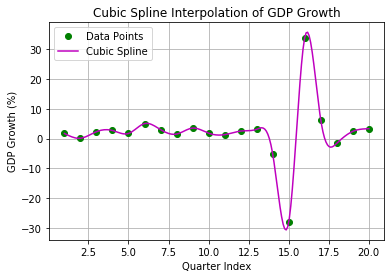

In [5]:
import numpy as np
import matplotlib.pyplot as plt


# Compute spacing between x values
def compute_h(x):
    h = []
    for i in range(len(x) - 1):
        h.append(x[i+1] - x[i])
    return h


# Build the tridiagonal system
def build_system(x, y):
    n = len(x)
    h = compute_h(x)

    A = [0] * (n-2)
    B = [0] * (n-2)
    C = [0] * (n-2)
    D = [0] * (n-2)

    for i in range(1, n-1):
        A[i-1] = h[i-1]
        B[i-1] = 2 * (h[i-1] + h[i])
        C[i-1] = h[i]
        D[i-1] = 6 * ((y[i+1] - y[i]) / h[i] - (y[i] - y[i-1]) / h[i-1])

    return A, B, C, D


# Thomas Algorithm used to solve the tridiagonal system
def thomas_algorithm(a, b, c, d):
    n = len(b)

    a = np.array(a, dtype=float)
    b = np.array(b, dtype=float)
    c = np.array(c, dtype=float)
    d = np.array(d, dtype=float)

    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]

    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]

    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]

    return x


# Function to compute the second derivative in order to get the curve or natural spline shape
def compute_E(x, y):
    n = len(x)

    A, B, C, D = build_system(x, y)
    E_internal = thomas_algorithm(A, B, C, D)

    E = np.zeros(n)
    E[1:n-1] = E_internal  # Solves the derivative of the internal points only as the edges are going to be 0

    return E


# Function to evaluate the spline shape at each given point
def evaluate_spline(x, y, E, x_eval):
    n = len(x)
    y_eval = []

    for xe in x_eval: # GPT used to implement the nested for loops
        S = 0
        found = False

        for i in range(n-1):
            if x[i] <= xe <= x[i+1]:
                hi = x[i+1] - x[i]
                #cubic spline code
                S = (
                    (E[i] / (6 * hi)) * (x[i+1] - xe)**3 +
                    (E[i+1] / (6 * hi)) * (xe - x[i])**3 +
                    (y[i] / hi - E[i] * hi / 6) * (x[i+1] - xe) +
                    (y[i+1] / hi - E[i+1] * hi / 6) * (xe - x[i])
                )
                found = True

        y_eval.append(S)

    return np.array(y_eval)



# This is the given GDP % Growth Dataset
y = np.array([
    1.7, 0.1, 2.3, 2.7, 1.7,
    5.0, 3.0, 1.5, 3.5, 1.8,
    1.3, 2.5, 3.1, -5.1, -28.1,
    33.8, 6.3, -1.6, 2.4, 3.3
])

# This gives an ordered set list for the x values to plot 
n = len(y)
x = np.array([i+1 for i in range(n)])


# Runs the Compute spline function
E = compute_E(x, y)

# Makes the points in between the given points so the curve is actually smooth
x_interp = np.linspace(1, n, 200)
y_spline = evaluate_spline(x, y, E, x_interp)


# Cubic Spline Plot
plt.figure()
plt.plot(x, y, 'go', label="Data Points")
plt.plot(x_interp, y_spline, 'm', label="Cubic Spline")
plt.title("Cubic Spline Interpolation of GDP Growth")
plt.xlabel("Quarter Index")
plt.ylabel("GDP Growth (%)")
plt.legend()
plt.grid()
plt.show()

__________________________________________________________

**POLYNOMIAL & LEAST SQAURES COMPARISON**

***Comparing Degree-4 Polynomial v.s. Cubic Spline***
 
   To complete a comparison between the cubic spline interpolation and a degree-4 polynomial approximation, both functions were run through the GDP growth dataset of 20 points from 2010 Q1 to 2023 Q4. Initial visual analysis shows that the cubic spline forms a curve such that it goes through every data point exactly. The degree-4 polynomial forms its curve by minimizing the sum of squared errors across all the given data points, which resulted in a line that does not pass through every single one of the points.

   Utilizing a more quantitative reasoning, the cubic spline has an MSE and RMSE of 0, confirming perfect interpolation. This is expected as this follows within the definition of a cubic spline function. The degree-4 polynomial, however, produces an MSE of approximately 99.31 and an RMSE of about 9.97, which directly correlates with its inability to capture extreme outliers such as the COVID-19 quarters between 2020 Q2 at -28.1% and 2020 Q3 at 33.8%. Completing an analysis on the predicted midpoints between consecutive quarters further highlights the distinction between the two functions. For example, at x = 1.50, the spline predicts 0.4908 and the polynomial predicts 0.8508; at x = 14.50, the spline closely follows the extreme drop and rebound due to COVID, whereas the polynomial naturally smooths these events into smaller values. This highlights the trade-off between exact interpolation and smooth approximation. The spline hits all the points, but is highly sensitive to each data point, while the polynomial captures the overall trend but cannot accurately show sharp deviations.

   Overall, it can be argued that the cubic spline is ideal for precise data reconstruction, particularly when exact reproduction of all points is mandatory. In this case, it is guaranteed that the graph created by a cubic spline function will include all the given data points. The spline function will ensure all points are met, even if that means the path towards the points is not fully accurate. The degree-4 polynomial, on the other hand, is better suited for trend analysis, providing a smoother representation while mitigating the influence of outliers.

***Least Squares Linear Model Excluding COVID***

   A separate analysis was conducted to clearly examine how the impact of these outliers had on the least squares function. For this reason, the exact quarters where COVID was known to cause the outlying GDP fluctuation were removed from the dataset before the least squares model was utilized. Quarters 2020 Q1–2021 Q1 were excluded. Ideally, removing these outliers should prevent the sharp extremes from negatively impacting the slope of the trend line for the linear least squares method.

   The resulting linear fit produces a slope of approximately 0.0126 and an intercept of 1.9045. This positive slope indicates a relative upward trend in GDP growth over the studied period of time. This upward trend is consistent with the overall economic growth outside of general crisis periods or extraneous scenarios such as COVID or a market crash. Residuals for the data points are relatively small and distributed evenly around zero. This suggests that a simple linear trend can help predict and show GDP behavior over a long period of time. While the linear model provides a useful approximation for long-term trends, it cannot account for short-term fluctuations or extreme events. In comparison, the cubic spline is precise at every quarter but overfits sharp changes, not accurately showing the path between points, and the polynomial provides a smoother curve that partially accounts for general trends but underestimates extreme variations.

   To summarize, the three methods serve their own unique purposes. Cubic splines should be utilized for exact interpolations of data. Degree-4 polynomials can be used for smoothed trend representation. And linear least squares, with preferably the major outliers removed, can be used for long-term growth trends. Both through graph analysis and quantitative measures such as MSE and RMSE, along with midpoint comparisons, support these assessments and clearly show the trade-offs between the methods.

Linear Model (COVID Quarters Excluded):
Slope (m): -0.0173
Intercept (c): 2.3041


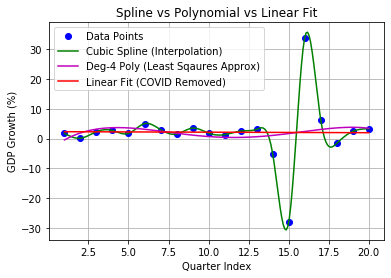

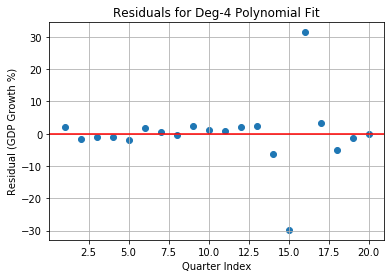

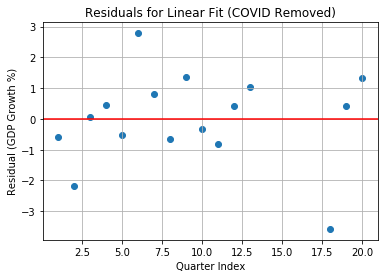

In [2]:
# Creating a vandermonde matrix, which uses the number of data points and the degree of polynomial to fit
def my_vandermonde(x, degree):
    n = len(x)
    A = np.zeros((n, degree + 1))

    for i in range(n):
        for j in range(degree + 1):
            A[i][j] = x[i]**j

    return A


# This solves the normal equations for least squares polynomial fitting by utilzing the vandermonde matrix
# Chat GPT utilized to implement ATA variables properly
def polynomial_fit(x, y, degree):
    A = my_vandermonde(x, degree)

    ATA = A.T @ A
    ATy = A.T @ y

    coeffs = np.linalg.solve(ATA, ATy)
    return coeffs


# Instead of using np.polyval this computes the predicted y values from the polynomial 
def evaluate_polynomial(coeffs, x_vals):
    y_vals = []

    for x in x_vals:
        y = 0
        for j in range(len(coeffs)):
            y += coeffs[j] * (x**j)
        y_vals.append(y)

    return np.array(y_vals)



# This function computes the slope and intercept so that I can manually make a line of best fit
def my_least_squares(X, Y):
    n = len(X)

    sum_x = np.sum(X)
    sum_y = np.sum(Y)
    sum_xy = np.sum(X * Y)
    sum_x2 = np.sum(X * X)

    m = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x**2)
    c = (sum_y - m * sum_x) / n

    return m, c



# Run the function for a cubic spline
E = compute_E(x, y)
x_interp = np.linspace(1, n, 200)
y_spline = evaluate_spline(x, y, E, x_interp)

# State the degree-4 polynomial
degree = 4
coeffs = polynomial_fit(x, y, degree)
y_poly = evaluate_polynomial(coeffs, x_interp)



# Exclude COVID data so remove 2020 Q1 → 2021 Q1
# Chat GPT used to learn about mask ability
mask = []
for i in range(n):
    if i not in [13, 14, 15, 16]:
        mask.append(True)
    else:
        mask.append(False)

mask = np.array(mask)

x_filtered = x[mask]
y_filtered = y[mask]

m, c = my_least_squares(x_filtered, y_filtered)

print("Linear Model (COVID Quarters Excluded):")
print(f"Slope (m): {m:.4f}")
print(f"Intercept (c): {c:.4f}")



# Main Plot with all uniquely created lines
plt.figure()

plt.plot(x, y, 'bo', label="Data Points")
plt.plot(x_interp, y_spline, 'g', label="Cubic Spline (Interpolation)")
plt.plot(x_interp, y_poly, 'm', label="Deg-4 Poly (Least Sqaures Approx)")
plt.plot(x, m*x + c, 'r', label="Linear Fit (COVID Removed)")

plt.title("Spline vs Polynomial vs Linear Fit")
plt.xlabel("Quarter Index")
plt.ylabel("GDP Growth (%)")
plt.legend()
plt.grid()
plt.show()


residuals_poly = y - evaluate_polynomial(coeffs, x)
residuals_linear = y_filtered - (m*x_filtered + c)

# Polynomial residual plot
plt.figure()
plt.scatter(x, residuals_poly)
plt.axhline(0, color='r')
plt.xlabel("Quarter Index")
plt.ylabel("Residual (GDP Growth %)")
plt.title("Residuals for Deg-4 Polynomial Fit")
plt.grid()
plt.show()

# Linear residual plot
plt.figure()
plt.scatter(x_filtered, residuals_linear)
plt.axhline(0, color='r')
plt.xlabel("Quarter Index")
plt.ylabel("Residual (GDP Growth %)")
plt.title("Residuals for Linear Fit (COVID Removed)")
plt.grid()
plt.show()

______________________________________________________________

**METHOD JUSTIFICATION**

***Recommendations For A Policymaker***
 
   For a policymaker who needs to estimate GDP growth for a quarter between two known data points, the cubic spline interpolation method is arguably the better function choice. Based on the results of this computational analysis, the spline produces exact interpolation with an MSE and RMSE of 0, meaning it passes through all known data points and provides highly accurate values between them. In contrast, the degree-4 polynomial has an MSE of approximately 99.31 and an RMSE of about 9.97, showing that it does not closely follow the data points exactly. This is especially notable near extreme values such as the COVID-19 quarters in this dataset. In terms of smoothness, the spline maintains continuous first and second derivatives, resulting in a smooth curve altogether without any sharp corners. While the polynomial is also smooth, it tends to completely miss sharp changes if there are any extreme data points. Additionally, the spline function is more sensitive to outliers, allowing it to capture extreme events more accurately, whereas the polynomial smooths over them. For this policymaker's interpolation purposes, this sensitivity is beneficial since the goal is to match the data as closely as possible.
   
***Big O Analysis***
 
   Big O notation describes how the runtime of an algorithm reacts as the size of the input increases. In general understanding, the more a function needs to compute, the longer it will take for the function to run. For the cubic spline specifically, the main computation comes from solving the tridiagonal system using the Thomas algorithm, which runs in O(n), and evaluating the spline, which is also approximately O(n). For the degree-4 polynomial, the main computation is constructing the Vandermonde matrix and solving the normal equations, which scales with O(n). A theoretical plot of known Big O growth rates (e.g., O(n), O(n²), O(n³)) helps show how these runtimes scale with increasing input size. Either way based on the timing results from the code, both methods run extremely quickly for the given dataset, with only small differences in runtime.

   Because both methods have similar complexity and fast runtimes for this relatively small dataset, the Big O analysis does not change the recommendation. However, if this analysis were applied to a much larger GDP dataset, the degree-4 polynomial may become slightly more efficient due to its low computational needs. Even in that case, the difference in runtime would likely remain small, and the choice of method would still depend more on accuracy. The polynomial method may be more efficient in some cases, but its loss in accuracy makes it less suitable for estimating values between known data points in this context.

In [7]:
import time 
import numpy as np

# Run the spline and derivative functions built
E = compute_E(x, y)
coeffs = polynomial_fit(x, y, degree=4)


# Chat GPT used to understand how to implement predictions at original data points
y_spline_pred = evaluate_spline(x, y, E, x)
y_poly_pred = evaluate_polynomial(coeffs, x)



# Function made for computing and collecting mean sqaured error. The smaller the better
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

# Function for root mean sqaured error which is just the square root of the mse
def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

# Spline error calculations 
mse_spline = mse(y, y_spline_pred)
rmse_spline = rmse(y, y_spline_pred)

# Polynomial error calculations
mse_poly = mse(y, y_poly_pred)
rmse_poly = rmse(y, y_poly_pred)


# Chat GPT used for clean formatting of error data
print("== Error Comparison ==")
print(f"Spline MSE: {mse_spline:.6f}")
print(f"Spline RMSE: {rmse_spline:.6f}")
print()
print(f"Polynomial MSE: {mse_poly:.6f}")
print(f"Polynomial RMSE: {rmse_poly:.6f}")


# Compares the spline and polynomial predictions with the actual data that is given
x_mid = (x[:-1] + x[1:]) / 2

y_spline_mid = evaluate_spline(x, y, E, x_mid)
y_poly_mid = evaluate_polynomial(coeffs, x_mid)


# Chat GPT used to understand how to properly dispaly the midpoint comparison data
print("\n== Sample Midpoint Interpolation Comparison: ==")
for i in range(5):
    print(f"x = {x_mid[i]:.2f} | Spline = {y_spline_mid[i]:.4f} | Polynomial = {y_poly_mid[i]:.4f}")


    
# Big O computations begin here:
# Timing the cubic spline using the GDP data
start = time.time()
E = compute_E(x, y)
y_spline_pred = evaluate_spline(x, y, E, x)
end = time.time()
spline_time = end - start

# Timing the polynomial deg-4 using the actual GDP data
start = time.time()
coeffs = polynomial_fit(x, y, degree=4)
y_poly_pred = evaluate_polynomial(coeffs, x)
end = time.time()
poly_time = end - start

print(f"\nCubic Spline Runtime: {spline_time:.6f} seconds")
print(f"Deg-4 Polynomial Runtime: {poly_time:.6f} seconds")




== Error Comparison ==
Spline MSE: 0.000000
Spline RMSE: 0.000000

Polynomial MSE: 99.307738
Polynomial RMSE: 9.965327

== Sample Midpoint Interpolation Comparison: ==
x = 1.50 | Spline = 0.4908 | Polynomial = 0.8508
x = 2.50 | Spline = 1.0027 | Polynomial = 2.6258
x = 3.50 | Spline = 2.9484 | Polynomial = 3.4801
x = 4.50 | Spline = 1.8035 | Polynomial = 3.6562
x = 5.50 | Spline = 3.3999 | Polynomial = 3.3685

Cubic Spline Runtime: 0.000702 seconds
Deg-4 Polynomial Runtime: 0.000375 seconds


__________________________________________________________

**CONCLUSION**

In conclusion, each method performed best in different situations depending on the goal of the analysis. The cubic spline was the most effective for interpolation, since it passes exactly through every data point and gives accurate values between known quarters. However, this also makes it very sensitive to extreme values, which can lead to unrealistic behavior between points. The degree-4 polynomial provided a smoother overall curve and was better at capturing general trends, but it does not accurately represent sharp changes in the data, and realistic scenarios like COVID can happen in any dataset. The linear least squares model, especially with the COVID outliers removed, was the most useful for understanding long-term growth trends, even though it ignores small short-term fluctuations. Overall, this project showed that no single method is perfect for all scenarios, and the best choice depends on whether accuracy, smoothness, or trend analysis is priority for the data analysis.

_______________________________________________________________________________________________

**REFERENCES**

United States, Bureau of Economic Analysis. "Table 1.1.1. Percent Change From Preceding Period in Real Gross Domestic Product." Bureau of Economic Analysis, www.bea.gov/data/gdp/gross-domestic-product. Accessed 27 Mar. 2026.